## Filtering periphery for # of genes per haplotype 

In [1]:
import os
import glob
import pandas as pd

In [2]:
CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
CENSAT_TSV_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_arrays/tables/censat_regions_pass_qc_by_chrom'

In [3]:
import re

def map_to_sat_category(raw):
    if raw is None: return "other"
    if   re.match(r'active_hor', raw, re.I): return "active_hor"
    elif re.match(r'dhor',       raw, re.I): return "dhor"
    elif re.match(r'hor',        raw, re.I): return "hor"
    elif re.match(r'mixedalpha', raw, re.I): return "mixedAlpha"
    elif re.match(r'mon',        raw, re.I): return "mon"
    elif re.search(r'hsat1',     raw, re.I): return "HSAT1"
    elif re.search(r'hsat2',     raw, re.I): return "HSAT2"
    elif re.search(r'hsat3',     raw, re.I): return "HSAT3"
    elif re.search(r'hsat4',     raw, re.I): return "HSAT4"
    elif re.search(r'hsat5',     raw, re.I): return "HSAT5"
    elif re.match(r'bsat',       raw, re.I): return "bSat"
    elif re.match(r'gsat',       raw, re.I): return "gSat"
    elif re.match(r'ct',         raw, re.I): return "CT"
    elif re.search(r'satr',      raw, re.I): return "SATR"
    elif re.search(r'sst1',      raw, re.I): return "SST1"
    elif re.search(r'cer',       raw, re.I): return "CER"
    elif re.search(r'rdna|5srna',raw, re.I): return "rDNA"
    elif re.search(r'acro',      raw, re.I): return "acrocentric"
    else:                                     return "other"


In [4]:
# load array boundaries
all_tsvs = glob.glob(f'{CENSAT_TSV_DIR}/censat_regions_pass_qc_chr*.tsv')
regions_df = pd.concat([pd.read_csv(f, sep='\t') for f in all_tsvs], ignore_index=True)
regions_df = regions_df[regions_df['pass_qc'] == True][
    ['sample_id', 'haplotype', 'chrom_assignment', 'sequence_id', 'region_start', 'region_end', 'pass_qc']
].rename(columns={'chrom_assignment': 'chrom'})
regions_df['haplotype'] = regions_df['haplotype'].astype(str)

### Original censat definitions

In [5]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages

CENSAT_BED_DIR = '/private/groups/migalab/juklucas/censat_regions/censat_beds'
OUTPUT_PDF     = '/private/groups/patenlab/mira/censat_arrays_all_chroms.pdf'
CHROM_ORDER    = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
ROW_H          = 0.12
CSAT_H         = 0.7

# ── build bed_map ─────────────────────────────────────────────────────────────
bed_map_v4 = {}
for path in glob.glob(f'{CENSAT_BED_DIR}/*.bed'):
    fname = os.path.basename(path)
    m = re.match(r'(.+?)_(hap\d+|mat|pat)_', fname)
    if not m: continue
    sid     = m.group(1)
    hap_raw = m.group(2)
    hap     = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')
    bed_map_v4[(sid, hap)] = path

print(f"bed_map entries: {len(bed_map_v4)}")

# ── load_censat ───────────────────────────────────────────────────────────────
def load_censat_v4(sample_id, haplotype, region):
    bed_path = bed_map_v4.get((sample_id, haplotype))
    if bed_path is None: return []
    seq = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    rows = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            start, end = max(start, rs), min(end, re_)
            try:    color = tuple(int(x)/255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            rows.append({'start': (start - rs)/1e6,
                         'end':   (end   - rs)/1e6,
                         'color': color})
    return rows

# ── one page per chrom ────────────────────────────────────────────────────────
with PdfPages(OUTPUT_PDF) as pdf:
    for chrom in CHROM_ORDER:
        chrom_regions = regions_df[
            (regions_df['chrom'] == chrom) & (regions_df['pass_qc'] == True)
        ].copy()
        chrom_regions['haplotype'] = chrom_regions['haplotype'].astype(str)
        chrom_regions = chrom_regions[
            chrom_regions.apply(
                lambda r: bed_map_v4.get((r['sample_id'], r['haplotype'])) is not None,
                axis=1)
        ].reset_index(drop=True)

        if len(chrom_regions) == 0:
            print(f"{chrom}: no haplotypes, skipping")
            continue

        max_size_mbp = (chrom_regions['region_end'] - chrom_regions['region_start']).max() / 1e6
        n = len(chrom_regions)
        print(f"{chrom}: {n} haplotypes, {max_size_mbp:.2f} Mbp", flush=True)

        fig, ax = plt.subplots(figsize=(16, n * ROW_H + 1.5))

        for yi, (_, row) in enumerate(chrom_regions.iterrows()):
            sid, hap = row['sample_id'], row['haplotype']
            for seg in load_censat_v4(sid, hap, row):
                ax.add_patch(mpatches.Rectangle(
                    (seg['start'], yi - CSAT_H/2),
                    seg['end'] - seg['start'], CSAT_H,
                    color=seg['color'], linewidth=0))

        ax.set_xlim(0, max_size_mbp)
        ax.set_ylim(-1, n)
        ax.invert_yaxis()
        ax.set_xlabel("CenSat position (Mbp)", fontsize=12)
        ax.set_yticks([])
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='x', labelsize=11)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
        ax.set_title(f"{chrom} — {n} QC-passing haplotypes", fontsize=13,
                     fontweight='bold', loc='left')

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"\nSaved {OUTPUT_PDF}")



bed_map entries: 462
chr1: 96 haplotypes, 32.11 Mbp
chr2: 144 haplotypes, 7.28 Mbp
chr3: 105 haplotypes, 11.90 Mbp
chr4: 107 haplotypes, 8.26 Mbp
chr5: 332 haplotypes, 9.03 Mbp
chr6: 197 haplotypes, 7.31 Mbp
chr7: 252 haplotypes, 11.00 Mbp
chr8: 321 haplotypes, 6.93 Mbp
chr9: 259 haplotypes, 31.70 Mbp
chr10: 307 haplotypes, 8.38 Mbp
chr11: 399 haplotypes, 10.69 Mbp
chr12: 368 haplotypes, 8.06 Mbp
chr13: 6 haplotypes, 15.25 Mbp
chr14: 16 haplotypes, 15.35 Mbp
chr15: 10 haplotypes, 18.92 Mbp
chr16: 213 haplotypes, 23.59 Mbp
chr17: 124 haplotypes, 8.64 Mbp
chr18: 120 haplotypes, 8.80 Mbp
chr19: 250 haplotypes, 13.62 Mbp
chr20: 220 haplotypes, 10.19 Mbp
chr21: 3 haplotypes, 10.25 Mbp
chr22: 3 haplotypes, 16.44 Mbp
chrX: 229 haplotypes, 5.52 Mbp
chrY: 9 haplotypes, 6.07 Mbp

Saved /private/groups/patenlab/mira/censat_arrays_all_chroms.pdf


rightmost mon: n=144  median=43.1 kb  mean=42.2 kb  min=23.3  max=47.7
leftmost HSAT3: n=144  median=28.4 kb  mean=29.1 kb  min=22.6  max=41.5


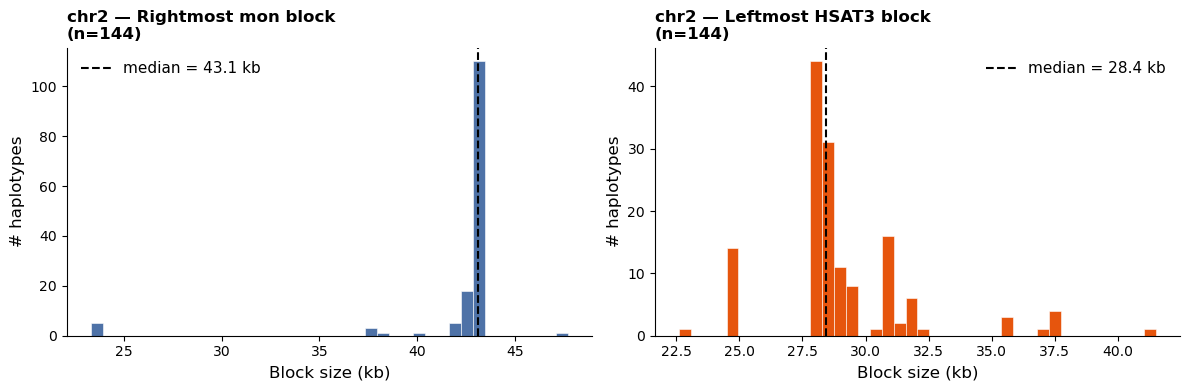

In [6]:
import re
import numpy as np
import matplotlib.pyplot as plt

def map_to_sat_category(raw):
    if raw is None: return "other"
    if   re.match(r'active_hor', raw, re.I): return "active_hor"
    elif re.match(r'dhor',       raw, re.I): return "dhor"
    elif re.match(r'hor',        raw, re.I): return "hor"
    elif re.match(r'mixedalpha', raw, re.I): return "mixedAlpha"
    elif re.match(r'mon',        raw, re.I): return "mon"
    elif re.search(r'hsat1',     raw, re.I): return "HSAT1"
    elif re.search(r'hsat2',     raw, re.I): return "HSAT2"
    elif re.search(r'hsat3',     raw, re.I): return "HSAT3"
    elif re.search(r'hsat4',     raw, re.I): return "HSAT4"
    elif re.search(r'hsat5',     raw, re.I): return "HSAT5"
    elif re.match(r'bsat',       raw, re.I): return "bSat"
    elif re.match(r'gsat',       raw, re.I): return "gSat"
    elif re.match(r'ct',         raw, re.I): return "CT"
    elif re.search(r'satr',      raw, re.I): return "SATR"
    elif re.search(r'sst1',      raw, re.I): return "SST1"
    elif re.search(r'cer',       raw, re.I): return "CER"
    elif re.search(r'rdna|5srna',raw, re.I): return "rDNA"
    elif re.search(r'acro',      raw, re.I): return "acrocentric"
    else:                                     return "other"

def first_block_size_kb(sample_id, haplotype, region, category, from_right=False):
    """Size in kb of the first block of `category` from left or right."""
    bed_path = bed_map_v4.get((sample_id, haplotype))
    if bed_path is None: return None
    seq = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    segs = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 4: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            if map_to_sat_category(cols[3]) != category: continue
            segs.append((max(start, rs), min(end, re_)))
    if not segs: return None
    segs.sort(key=lambda x: x[0], reverse=from_right)
    start, end = segs[0]
    return (end - start) / 1e3

# ── chr2 regions ──────────────────────────────────────────────────────────────
chr2_regions = regions_df[
    (regions_df['chrom'] == 'chr2') & (regions_df['pass_qc'] == True)
].copy()
chr2_regions['haplotype'] = chr2_regions['haplotype'].astype(str)
chr2_regions = chr2_regions[
    chr2_regions.apply(
        lambda r: bed_map_v4.get((r['sample_id'], r['haplotype'])) is not None, axis=1)
].reset_index(drop=True)

# ── collect sizes ─────────────────────────────────────────────────────────────
mon_sizes   = []
hsat3_sizes = []

for _, row in chr2_regions.iterrows():
    m = first_block_size_kb(row['sample_id'], row['haplotype'], row, 'mon',   from_right=True)
    h = first_block_size_kb(row['sample_id'], row['haplotype'], row, 'HSAT3', from_right=False)
    if m is not None: mon_sizes.append(m)
    if h is not None: hsat3_sizes.append(h)

mon_sizes   = np.array(mon_sizes)
hsat3_sizes = np.array(hsat3_sizes)

for label, sizes in [("rightmost mon", mon_sizes), ("leftmost HSAT3", hsat3_sizes)]:
    print(f"{label}: n={len(sizes)}  median={np.median(sizes):.1f} kb  "
          f"mean={np.mean(sizes):.1f} kb  min={np.min(sizes):.1f}  max={np.max(sizes):.1f}")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, sizes, label, color in [
    (axes[0], mon_sizes,   "Rightmost mon block",   "#4E72A7"),
    (axes[1], hsat3_sizes, "Leftmost HSAT3 block",  "#e6550d"),
]:
    ax.hist(sizes, bins=40, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(np.median(sizes), color='black', lw=1.5, linestyle='--',
               label=f"median = {np.median(sizes):.1f} kb")
    ax.set_xlabel("Block size (kb)", fontsize=12)
    ax.set_ylabel("# haplotypes", fontsize=12)
    ax.set_title(f"chr2 — {label}\n(n={len(sizes)})", fontsize=12,
                 fontweight='bold', loc='left')
    ax.legend(frameon=False, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()



chr7 leftmost mon: n=252  median=249.6 kb  mean=239.4 kb  min=2.3  max=305.8


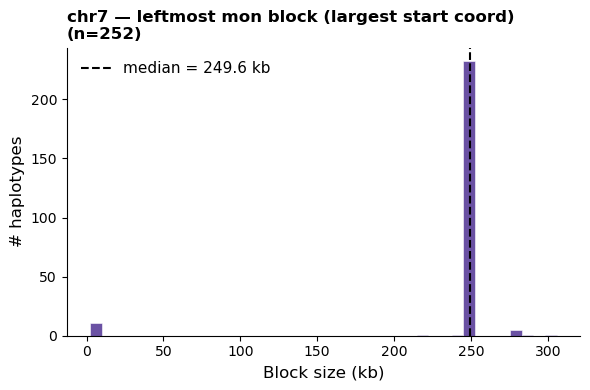

In [7]:
chr7_regions = regions_df[
    (regions_df['chrom'] == 'chr7') & (regions_df['pass_qc'] == True)
].copy()
chr7_regions['haplotype'] = chr7_regions['haplotype'].astype(str)
chr7_regions = chr7_regions[
    chr7_regions.apply(
        lambda r: bed_map_v4.get((r['sample_id'], r['haplotype'])) is not None, axis=1)
].reset_index(drop=True)

mon_sizes_chr7 = []
for _, row in chr7_regions.iterrows():
    m = first_block_size_kb(row['sample_id'], row['haplotype'], row, 'mon', from_right=True)
    if m is not None:
        mon_sizes_chr7.append(m)

mon_sizes_chr7 = np.array(mon_sizes_chr7)
print(f"chr7 leftmost mon: n={len(mon_sizes_chr7)}  median={np.median(mon_sizes_chr7):.1f} kb  "
      f"mean={np.mean(mon_sizes_chr7):.1f} kb  min={np.min(mon_sizes_chr7):.1f}  max={np.max(mon_sizes_chr7):.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mon_sizes_chr7, bins=40, color='#6a51a3', edgecolor='white', linewidth=0.4)
ax.axvline(np.median(mon_sizes_chr7), color='black', lw=1.5, linestyle='--',
           label=f"median = {np.median(mon_sizes_chr7):.1f} kb")
ax.set_xlabel("Block size (kb)", fontsize=12)
ax.set_ylabel("# haplotypes", fontsize=12)
ax.set_title(f"chr7 — leftmost mon block (largest start coord)\n(n={len(mon_sizes_chr7)})",
             fontsize=12, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


chr9 first mon (leftmost): n=259  median=68.4 kb  mean=67.0 kb  min=3.2  max=90.8


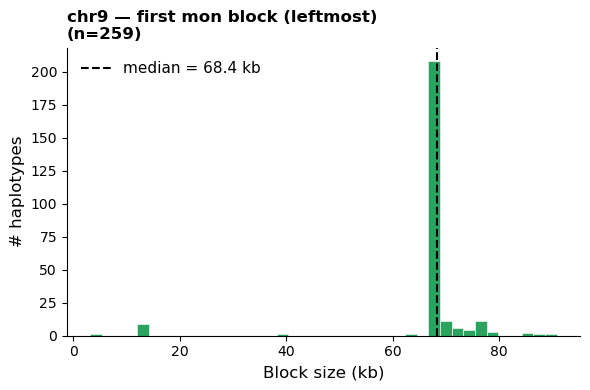

In [8]:
chr9_regions = regions_df[
    (regions_df['chrom'] == 'chr9') & (regions_df['pass_qc'] == True)
].copy()
chr9_regions['haplotype'] = chr9_regions['haplotype'].astype(str)
chr9_regions = chr9_regions[
    chr9_regions.apply(
        lambda r: bed_map_v4.get((r['sample_id'], r['haplotype'])) is not None, axis=1)
].reset_index(drop=True)

mon_sizes_chr9 = []
for _, row in chr9_regions.iterrows():
    m = first_block_size_kb(row['sample_id'], row['haplotype'], row, 'mon', from_right=False)
    if m is not None:
        mon_sizes_chr9.append(m)

mon_sizes_chr9 = np.array(mon_sizes_chr9)
print(f"chr9 first mon (leftmost): n={len(mon_sizes_chr9)}  "
      f"median={np.median(mon_sizes_chr9):.1f} kb  "
      f"mean={np.mean(mon_sizes_chr9):.1f} kb  "
      f"min={np.min(mon_sizes_chr9):.1f}  max={np.max(mon_sizes_chr9):.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mon_sizes_chr9, bins=40, color='#2ca25f', edgecolor='white', linewidth=0.4)
ax.axvline(np.median(mon_sizes_chr9), color='black', lw=1.5, linestyle='--',
           label=f"median = {np.median(mon_sizes_chr9):.1f} kb")
ax.set_xlabel("Block size (kb)", fontsize=12)
ax.set_ylabel("# haplotypes", fontsize=12)
ax.set_title(f"chr9 — first mon block (leftmost)\n(n={len(mon_sizes_chr9)})",
             fontsize=12, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


- chr1: keep everything to the left of the first HSAT2 array from the end (has the largest start coordinate) thats > 500 kbp (and keep the first HSAT2 array thats > 500 kbp from the end)
- chr2: Keep everything to the right of the first HSAT3 block > 22.5 kb (including keeping that first HSAT3 block > 22.5 kb), left of the first mon block that is > 10 kb(keeping the mon block)
- chr6: right hand side is good, remove everything to the left of the first encountered cenSAT(SATR1,SATR2) block, keeping the cenSAT(SATR1,SATR2) block
- chr7: for non inverted haplotypes: from the right hand side remove anything to the right of the mon block with the largest start coordinate that is > 200 kb, keeping the mon block. For the inverted haplotypes (NA19185.1, NA18879.1, NA19338.2), don't do any trimming 
- chr8: cut everything to the right of the first mon block from the start coordinate, keeping the mon block. 
- chr9: remove everything to the right of the first HSAT3 from the end thats > 1Mb, keeping the HSAT3 array. Remove everything to the left of the first mon from the start coord thats > 50kb , keeping the mon block 
- chr16: remove everything to the left of the first HSAT2 or HSAT3 encountered from the start coord, keeping the first HSAT2 or HSAT3 

In [9]:
import os, glob, re, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages

OUTPUT_PDF_TRIMMED = '/private/groups/patenlab/mira/censat_arrays_trimmed.pdf'
CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
ROW_H  = 0.12
CSAT_H = 0.7

ALPHA_SAT_CATS = {'active_hor', 'hor', 'dhor', 'mixedAlpha'}

def has_block_before(sample_id, haplotype, region, categories, before_coord):
    """Return True if any block of `categories` has start < before_coord."""
    bed_path = bed_map_v4.get((sample_id, haplotype))
    if bed_path is None: return False
    seq = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 4: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            if map_to_sat_category(cols[3]) not in categories: continue
            if start < before_coord:
                return True
    return False


# ── find_block: return (genomic_start, genomic_end) of qualifying block ───────
def find_block(sample_id, haplotype, region, categories, min_size_bp=0, from_right=False):
    bed_path = bed_map_v4.get((sample_id, haplotype))
    if bed_path is None: return None
    seq  = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    segs = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 4: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            cat = map_to_sat_category(cols[3])
            if cat not in categories: continue
            start, end = max(start, rs), min(end, re_)
            if (end - start) < min_size_bp: continue
            segs.append((start, end))
    if not segs: return None
    segs.sort(key=lambda x: x[0], reverse=from_right)
    return segs[0]

# ── per-chrom trimming rules ───────────────────────────────────────────────────
INVERTED_CHR7 = {'NA19185.1', 'NA18879.1', 'NA19338.2'}

INVERTED_CHR7 = {'NA19185.1', 'NA18879.1', 'NA19338.2'}

def trim_region(row):
    sid, hap, chrom = row['sample_id'], row['haplotype'], row['chrom']
    new_start, new_end = row['region_start'], row['region_end']

    if chrom == 'chr1':
        # right trim: keep through end of rightmost HSAT2 > 500 kbp
        blk = find_block(sid, hap, row, {'HSAT2'}, min_size_bp=500_000, from_right=True)
        if blk: new_end = blk[1]                          # keep the block

    elif chrom == 'chr2':
        # left trim: keep from start of leftmost HSAT3 > 22.5 kb
        blk_l = find_block(sid, hap, row, {'HSAT3'}, min_size_bp=22_500, from_right=False)
        # right trim: keep through end of rightmost mon > 10 kb
        blk_r = find_block(sid, hap, row, {'mon'},   min_size_bp=10_000, from_right=True)
        if blk_l: new_start = blk_l[0]                    # keep the block
        if blk_r: new_end   = blk_r[1]                    # keep the block

    elif chrom == 'chr6':
        # left trim: keep from start of leftmost SATR block
        blk = find_block(sid, hap, row, {'SATR'}, min_size_bp=0, from_right=False)
        if blk: new_start = blk[0]                        # keep the block

    elif chrom == 'chr7':
        sample_hap = f"{sid}.{hap}"
        if sample_hap not in INVERTED_CHR7:
            # right trim: keep through end of rightmost mon > 200 kb
            blk = find_block(sid, hap, row, {'mon'}, min_size_bp=200_000, from_right=True)
            if blk: new_end = blk[1]                      # keep the block

    elif chrom == 'chr8':
        # right trim: keep through end of leftmost mon block
        blk = find_block(sid, hap, row, {'mon'}, min_size_bp=0, from_right=False)
        if blk: new_end = blk[1]                          # keep the block

    elif chrom == 'chr9':
        # right trim: keep through end of rightmost HSAT3 > 1 Mb
        blk_r = find_block(sid, hap, row, {'HSAT3'}, min_size_bp=1_000_000, from_right=True)
        # left trim: keep from start of leftmost mon > 50 kb
        blk_l = find_block(sid, hap, row, {'mon'},   min_size_bp=50_000,    from_right=False)
        if blk_r: new_end   = blk_r[1]                    # keep the block
        if blk_l: new_start = blk_l[0]                    # keep the block

    elif chrom == 'chr16':
        # left trim: keep from start of leftmost HSAT2 or HSAT3
        blk = find_block(sid, hap, row, {'HSAT2', 'HSAT3'}, min_size_bp=0, from_right=False)
        if blk:
            # skip trim if any alpha sat lies to the left of this block
            if not has_block_before(sid, hap, row, ALPHA_SAT_CATS, before_coord=blk[0]):
                new_start = blk[0]


    return new_start, new_end


# ── build regions_trimmed ─────────────────────────────────────────────────────
pass_regions = regions_df[regions_df['pass_qc'] == True].copy()
pass_regions['haplotype'] = pass_regions['haplotype'].astype(str)
pass_regions = pass_regions[
    pass_regions.apply(
        lambda r: bed_map_v4.get((r['sample_id'], r['haplotype'])) is not None, axis=1)
].reset_index(drop=True)

trim_coords = pass_regions.apply(trim_region, axis=1, result_type='expand')
trim_coords.columns = ['region_start', 'region_end']
regions_trimmed = pass_regions.copy()
regions_trimmed[['region_start', 'region_end']] = trim_coords
print(f"regions_trimmed: {len(regions_trimmed)} rows")

# ── load_censat clipped to trimmed bounds ─────────────────────────────────────
def load_censat_trimmed(sample_id, haplotype, region):
    bed_path = bed_map_v4.get((sample_id, haplotype))
    if bed_path is None: return []
    seq      = region['sequence_id'].split('#')[-1]
    rs, re_  = region['region_start'], region['region_end']
    rows = []
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 9: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            start, end = max(start, rs), min(end, re_)
            try:    color = tuple(int(x)/255 for x in cols[8].split(','))
            except: color = (0.5, 0.5, 0.5)
            rows.append({'start': (start - rs)/1e6,
                         'end':   (end   - rs)/1e6,
                         'color': color})
    return rows

# ── PDF: one page per chrom ───────────────────────────────────────────────────
with PdfPages(OUTPUT_PDF_TRIMMED) as pdf:
    for chrom in CHROM_ORDER:
        chrom_regions = regions_trimmed[regions_trimmed['chrom'] == chrom].copy().reset_index(drop=True)
        if len(chrom_regions) == 0:
            print(f"{chrom}: no haplotypes, skipping")
            continue

        max_size_mbp = (chrom_regions['region_end'] - chrom_regions['region_start']).max() / 1e6
        n = len(chrom_regions)
        print(f"{chrom}: {n} haplotypes, {max_size_mbp:.2f} Mbp", flush=True)

        fig, ax = plt.subplots(figsize=(16, n * ROW_H + 1.5))

        for yi, (_, row) in enumerate(chrom_regions.iterrows()):
            for seg in load_censat_trimmed(row['sample_id'], row['haplotype'], row):
                ax.add_patch(mpatches.Rectangle(
                    (seg['start'], yi - CSAT_H/2),
                    seg['end'] - seg['start'], CSAT_H,
                    color=seg['color'], linewidth=0))

        ax.set_xlim(0, max_size_mbp)
        ax.set_ylim(-1, n)
        ax.invert_yaxis()
        ax.set_xlabel("CenSat position (Mbp)", fontsize=12)
        ax.set_yticks([])
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='x', labelsize=11)
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.1))
        ax.set_title(f"{chrom} — {n} QC-passing haplotypes (trimmed)", fontsize=13,
                     fontweight='bold', loc='left')

        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"\nSaved {OUTPUT_PDF_TRIMMED}")


regions_trimmed: 4090 rows
chr1: 96 haplotypes, 30.45 Mbp
chr2: 144 haplotypes, 6.05 Mbp
chr3: 105 haplotypes, 11.90 Mbp
chr4: 107 haplotypes, 8.26 Mbp
chr5: 332 haplotypes, 9.03 Mbp
chr6: 197 haplotypes, 6.94 Mbp
chr7: 252 haplotypes, 11.00 Mbp
chr8: 321 haplotypes, 0.48 Mbp
chr9: 259 haplotypes, 30.06 Mbp
chr10: 307 haplotypes, 8.38 Mbp
chr11: 399 haplotypes, 10.69 Mbp
chr12: 368 haplotypes, 8.06 Mbp
chr13: 6 haplotypes, 15.25 Mbp
chr14: 16 haplotypes, 15.35 Mbp
chr15: 10 haplotypes, 18.92 Mbp
chr16: 213 haplotypes, 22.41 Mbp
chr17: 124 haplotypes, 8.64 Mbp
chr18: 120 haplotypes, 8.80 Mbp
chr19: 250 haplotypes, 13.62 Mbp
chr20: 220 haplotypes, 10.19 Mbp
chr21: 3 haplotypes, 10.25 Mbp
chr22: 3 haplotypes, 16.44 Mbp
chrX: 229 haplotypes, 5.52 Mbp
chrY: 9 haplotypes, 6.07 Mbp

Saved /private/groups/patenlab/mira/censat_arrays_trimmed.pdf


In [10]:
import glob, re
import os
import pandas as pd

ANNOT_DIR = '/private/groups/patenlab/mira/centrolign/analysis/Fig1_genes/annotate_censat_prajnas_list'

COL_NAMES = ['contig', 'source', 'feature', 'start', 'end',
             'score', 'strand', 'phase', 'attributes', 'contig2', 'overlap_bp', 'censat_annot']

def parse_attr(attr_str, key):
    m = re.search(rf'{key}=([^;]+)', attr_str)
    return m.group(1) if m else None

records = []
for path in glob.glob(f'{ANNOT_DIR}/*_censat_annot.tsv'):
    fname  = os.path.basename(path)
    m      = re.match(r'(.+?)_(hap\d+|mat|pat)_(chr\w+)_censat_annot\.tsv', fname)
    if not m: continue
    sample_id  = m.group(1)
    hap_raw    = m.group(2)
    chrom      = m.group(3)
    haplotype  = hap_raw.replace('hap', '').replace('mat', '2').replace('pat', '1')

    df = pd.read_csv(path, sep='\t', header=None, names=COL_NAMES, low_memory=False)
    df = df[df['feature'] == 'gene'].copy()

    df['sample_id']  = sample_id
    df['haplotype']  = haplotype
    df['chrom']      = chrom
    df['gene_name']  = df['attributes'].apply(lambda x: parse_attr(x, 'gene_name'))
    df['gene_biotype'] = df['attributes'].apply(lambda x: parse_attr(x, 'gene_biotype'))

    records.append(df[['sample_id', 'haplotype', 'chrom', 'contig',
                        'start', 'end', 'strand', 'gene_name', 'gene_biotype',
                        'censat_annot']])

annot_df = pd.concat(records, ignore_index=True)
annot_df['start'] = annot_df['start'].astype(int)
annot_df['end']   = annot_df['end'].astype(int)

print(annot_df.shape)
display(annot_df.head())

(170894, 10)


,sample_id,haplotype,chrom,contig,start,end,strand,gene_name,gene_biotype,censat_annot
0,HG03540,1,chr18,CM088058.1,14179394,14180956,+,FRG2LP,processed_pseudogene,ct(100.0%)
1,HG03540,1,chr18,CM088058.1,14194685,14199045,-,NF1P5,transcribed_processed_pseudogene,ct(100.0%)
2,HG03540,1,chr18,CM088058.1,14220598,14263255,+,ANKRD20A5P,lncRNA,ct(100.0%)
3,HG03540,1,chr18,CM088058.1,14221095,14286500,+,ANKRD20A5P,transcribed_unprocessed_pseudogene,ct(100.0%)
4,HG03540,1,chr18,CM088058.1,14232400,14232506,+,RNU6-316P,snRNA,ct(100.0%)


In [ ]:
# list of genes in trimmed regions without biotype filters
merged_all = annot_df.merge(
    regions_trimmed[['sample_id', 'haplotype', 'chrom', 'region_start', 'region_end']],
    on=['sample_id', 'haplotype', 'chrom'],
    how='inner'
)

annot_trimmed_all = merged_all[
    (merged_all['start'] < merged_all['region_end']) &
    (merged_all['end']   > merged_all['region_start'])
].drop(columns=['region_start', 'region_end']).reset_index(drop=True)

print(f"annot_df (all biotypes):     {len(annot_df):,} rows")
print(f"after trimmed region filter: {len(annot_trimmed_all):,} rows")
print(f"unique genes: {annot_trimmed_all['gene_name'].nunique()}")

annot_trimmed_all.to_csv('/private/groups/patenlab/mira/annot_trimmed_all_biotypes.csv', index=False)
print(f"Wrote {len(annot_trimmed_all):,} rows to annot_trimmed_all_biotypes.csv")


annot_df (all biotypes):     170,894 rows
after trimmed region filter: 143,503 rows
unique genes: 1347
Wrote 143,503 rows to annot_trimmed_all_biotypes.csv


In [11]:
# plot number of genes per haplotype for only lncRNA and protein coding 

In [12]:
# biotype filter
KEEP_BIOTYPES = {'protein_coding', 'lncRNA'}
annot_filt = annot_df[annot_df['gene_biotype'].isin(KEEP_BIOTYPES)].copy()

# merge with trimmed regions on sample/hap/chrom
merged = annot_filt.merge(
    regions_trimmed[['sample_id', 'haplotype', 'chrom', 'region_start', 'region_end']],
    on=['sample_id', 'haplotype', 'chrom'],
    how='inner'
)

# keep genes that overlap the trimmed region
annot_trimmed = merged[
    (merged['start'] < merged['region_end']) &
    (merged['end']   > merged['region_start'])
].drop(columns=['region_start', 'region_end']).reset_index(drop=True)

print(f"annot_df (all biotypes):        {len(annot_df):,} rows")
print(f"after biotype filter:           {len(annot_filt):,} rows")
print(f"after trimmed region filter:    {len(annot_trimmed):,} rows")
print(f"unique genes: {annot_trimmed['gene_name'].nunique()}")


annot_df (all biotypes):        170,894 rows
after biotype filter:           40,847 rows
after trimmed region filter:    34,503 rows
unique genes: 258


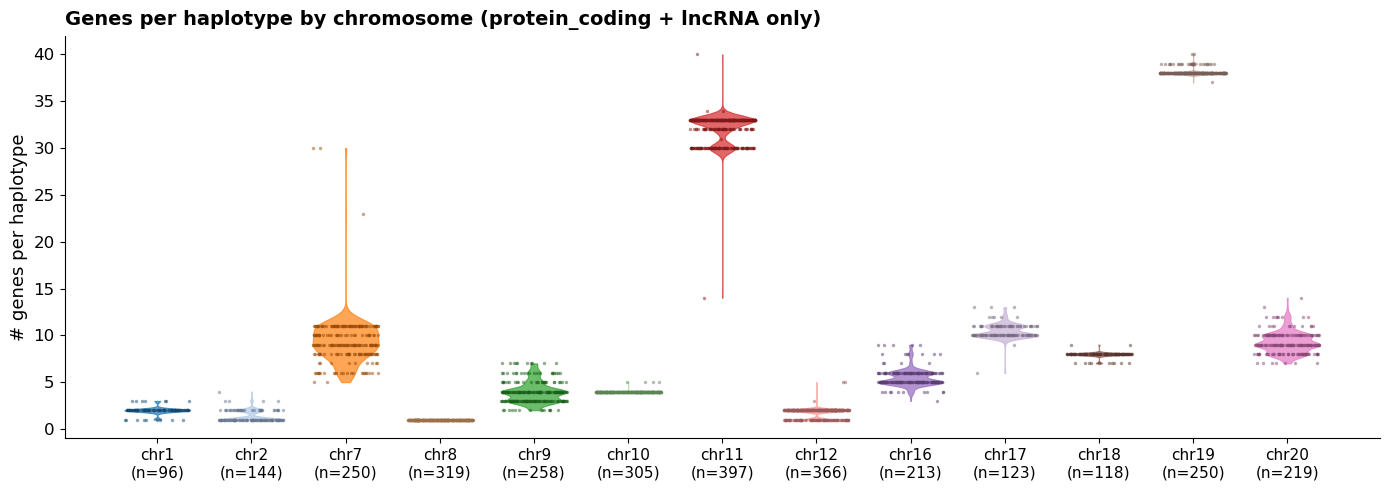

In [13]:
### REMOVED  snoRNAs, snRNAs, miscRNAs, IG genes and rDNAs, as well as chroms with less than 20 samples having any genes per hap


import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

annot_pc_lnc = annot_trimmed[
    annot_trimmed["gene_biotype"].isin(["protein_coding", "lncRNA"])
].copy()

per_hap_chrom = (
    annot_pc_lnc.groupby(["sample_id", "haplotype", "chrom"])
    .size().reset_index(name="count")
)

chrom_n = per_hap_chrom.groupby("chrom").size()
CHROM_ORDER = [c for c in CHROM_ORDER if chrom_n.get(c, 0) >= 20]

chrom_colors = {chrom: cm.tab20(i % 20) for i, chrom in enumerate(CHROM_ORDER)}

def darken(color, factor=0.6):
    r, g, b, *a = mcolors.to_rgba(color)
    return (r * factor, g * factor, b * factor, 1)

def make_violin_panel(ax, data, x_col, x_order, title, color_map=None, default_color="#4E72A7"):
    valid = [c for c in x_order if c in data[x_col].unique()]
    for xi, cat in enumerate(valid):
        vals  = data[data[x_col] == cat]["count"].values
        color = color_map[cat] if color_map and cat in color_map else default_color
        if len(vals) >= 3:
            parts = ax.violinplot(vals, positions=[xi], widths=0.7,
                                  showextrema=False, showmedians=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(color)
                pc.set_alpha(0.7)
                pc.set_edgecolor(color)
                pc.set_linewidth(0.8)
        if len(vals) > 0:
            dark   = darken(color)
            jitter = np.random.uniform(-0.35, 0.35, size=len(vals))
            ax.scatter(np.full(len(vals), xi) + jitter, vals,
                       color=dark, alpha=0.5, s=6, linewidths=0, zorder=6)

    ax.set_xticks(range(len(valid)))
    xlabels = [f"{cat}\n(n={len(data[data[x_col]==cat])})" for cat in valid]
    ax.set_xticklabels(xlabels, rotation=0, ha="center", fontsize=11)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=8, loc="left")
    ax.set_ylabel("# genes per haplotype", fontsize=13)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=12)

np.random.seed(42)
fig, ax = plt.subplots(figsize=(14, 5))

make_violin_panel(ax, per_hap_chrom, "chrom", CHROM_ORDER,
                  "Genes per haplotype by chromosome (protein_coding + lncRNA only)",
                  color_map=chrom_colors)

plt.tight_layout()
plt.show()


In [14]:
annot_pc_lnc.to_csv('/private/groups/patenlab/mira/annot_pc_lnc.csv', index=False)
print(f"Wrote {len(annot_pc_lnc):,} rows to annot_pc_lnc.csv")


Wrote 34,503 rows to annot_pc_lnc.csv


In [15]:
# plot for every chrom, percent of genes in each satellite class, and plot # of genes vs # Mb CT

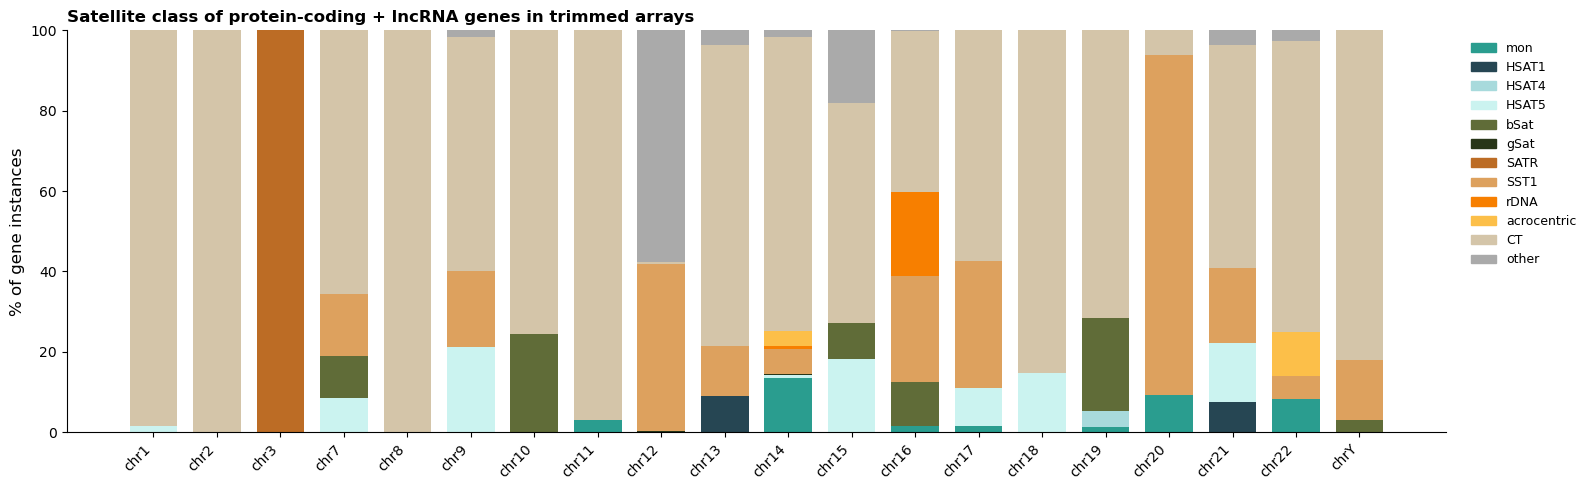

sat_cat  active_hor  hor  dhor  mixedAlpha   mon  HSAT1  HSAT2  HSAT3  HSAT4  HSAT5  bSat  gSat   SATR  SST1  CER  rDNA  acrocentric     CT  other
chrom                                                                                                                                             
chr1            0.0  0.0   0.0         0.0   0.0    0.0    0.0    0.0    0.0    1.6   0.0   0.0    0.0   0.0  0.0   0.0          0.0   98.4    0.0
chr2            0.0  0.0   0.0         0.0   0.0    0.0    0.0    0.0    0.0    0.0   0.0   0.0    0.0   0.0  0.0   0.0          0.0  100.0    0.0
chr3            0.0  0.0   0.0         0.0   0.0    0.0    0.0    0.0    0.0    0.0   0.0   0.0  100.0   0.0  0.0   0.0          0.0    0.0    0.0
chr7            0.0  0.0   0.0         0.0   0.0    0.0    0.0    0.0    0.0    8.6  10.4   0.0    0.0  15.4  0.0   0.0          0.0   65.6    0.0
chr8            0.0  0.0   0.0         0.0   0.0    0.0    0.0    0.0    0.0    0.0   0.0   0.0    0.0   0.0  0.0   0.

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import re

def dominant_sat_cat(annot_str):
    """Parse 'active_hor(85%),mon(15%)' and return the category with highest %."""
    if not isinstance(annot_str, str) or annot_str.strip() == '':
        return 'other'
    best_cat, best_pct = 'other', -1
    for part in annot_str.split(','):
        part = part.strip()
        m = re.match(r'(.+?)\((\d+(?:\.\d+)?)%\)', part)
        if m:
            raw_cat = m.group(1).strip()
            pct     = float(m.group(2))
            cat     = map_to_sat_category(raw_cat)
            if pct > best_pct:
                best_pct, best_cat = pct, cat
        else:
            # no percentage annotation — treat as sole category
            cat = map_to_sat_category(part)
            if best_pct < 0:
                best_cat = cat
    return best_cat

SAT_ORDER = [
    "active_hor", "hor", "dhor", "mixedAlpha", "mon",
    "HSAT1", "HSAT2", "HSAT3", "HSAT4", "HSAT5",
    "bSat", "gSat", "SATR", "SST1", "CER",
    "rDNA", "acrocentric", "CT", "other",
]

SAT_COLORS = {
    "active_hor":  "#E63946",
    "hor":         "#F4A261",
    "dhor":        "#E9C46A",
    "mixedAlpha":  "#FFBA08",
    "mon":         "#2A9D8F",
    "HSAT1":       "#264653",
    "HSAT2":       "#457B9D",
    "HSAT3":       "#1D3557",
    "HSAT4":       "#A8DADC",
    "HSAT5":       "#CBF3F0",
    "bSat":        "#606C38",
    "gSat":        "#283618",
    "SATR":        "#BC6C25",
    "SST1":        "#DDA15E",
    "CER":         "#D62828",
    "rDNA":        "#F77F00",
    "acrocentric": "#FCBF49",
    "CT":          "#D4C5A9",
    "other":       "#AAAAAA",
}

# map censat_annot → category
# replace the previous single-call mapping
annot_trimmed['sat_cat'] = annot_trimmed['censat_annot'].apply(dominant_sat_cat)

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
chroms = [c for c in CHROM_ORDER if c in annot_trimmed['chrom'].unique()]

# count gene-instances per (chrom, sat_cat), then normalize to %
counts = (
    annot_trimmed
    .groupby(['chrom', 'sat_cat'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=chroms, columns=SAT_ORDER, fill_value=0)
)
pct = counts.div(counts.sum(axis=1), axis=0) * 100

# ── stacked bar ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

bottom = np.zeros(len(chroms))
for cat in SAT_ORDER:
    if cat not in pct.columns or pct[cat].sum() == 0:
        continue
    ax.bar(range(len(chroms)), pct[cat].values, bottom=bottom,
           color=SAT_COLORS.get(cat, '#AAAAAA'), label=cat, width=0.75)
    bottom += pct[cat].values

ax.set_xticks(range(len(chroms)))
ax.set_xticklabels(chroms, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('% of gene instances', fontsize=12)
ax.set_ylim(0, 100)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Satellite class of protein-coding + lncRNA genes in trimmed arrays',
             fontsize=12, fontweight='bold', loc='left')

shown = [c for c in SAT_ORDER if c in pct.columns and pct[c].sum() > 0]
handles = [mpatches.Patch(color=SAT_COLORS[c], label=c) for c in shown]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

# quick summary table
print(pct.round(1).to_string())


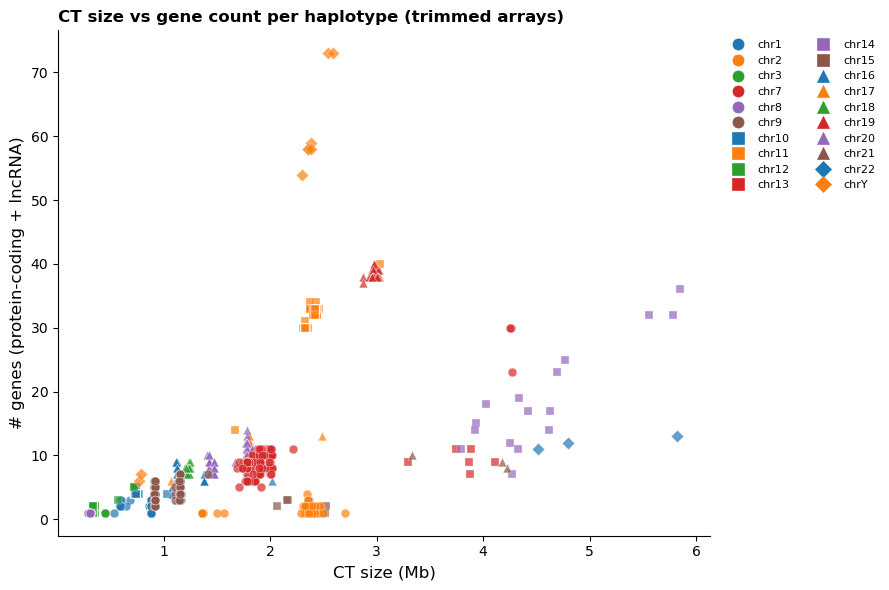

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Step 1: compute CT Mb per haplotype/chrom from trimmed regions ────────────
def compute_ct_mb(sample_id, haplotype, region):
    bed_path = bed_map_v4.get((sample_id, haplotype))
    if bed_path is None: return 0.0
    seq = region['sequence_id'].split('#')[-1]
    rs, re_ = region['region_start'], region['region_end']
    total = 0
    with open(bed_path) as f:
        for line in f:
            if line.startswith('track'): continue
            cols = line.strip().split('\t')
            if len(cols) < 4: continue
            s_parts = cols[0].split('#')
            s = s_parts[2] if len(s_parts) == 3 else cols[0]
            if s != seq: continue
            start, end = int(cols[1]), int(cols[2])
            if end < rs or start > re_: continue
            if map_to_sat_category(cols[3]) != 'CT': continue
            total += min(end, re_) - max(start, rs)
    return total / 1e6

ct_records = []
for _, row in regions_trimmed.iterrows():
    ct_records.append({
        'sample_id': row['sample_id'],
        'haplotype': row['haplotype'],
        'chrom':     row['chrom'],
        'ct_mb':     compute_ct_mb(row['sample_id'], row['haplotype'], row),
    })
ct_df = pd.DataFrame(ct_records)

# ── Step 2: gene counts per haplotype/chrom ───────────────────────────────────
gene_counts = (
    annot_trimmed
    .groupby(['sample_id', 'haplotype', 'chrom'])
    .size()
    .reset_index(name='n_genes')
)

# ── Step 3: merge ─────────────────────────────────────────────────────────────
plot_df = gene_counts.merge(ct_df, on=['sample_id', 'haplotype', 'chrom'], how='inner')
plot_df = plot_df[plot_df['ct_mb'] > 0]   # drop haplotypes with no CT

# ── Step 4: chrom → color + marker ───────────────────────────────────────────
import matplotlib.cm as cm

CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
chroms = [c for c in CHROM_ORDER if c in plot_df['chrom'].unique()]

COLORS = [cm.tab10(i) for i in range(6)]   # 6 colors → marker advances every 6 chroms
MARKERS_FILLED = ['o', 's', '^', 'D', 'v', 'P', 'X', 'h', 'p', '<']

chrom_color  = {c: COLORS[i % len(COLORS)]                                   for i, c in enumerate(chroms)}
chrom_marker = {c: MARKERS_FILLED[(i // len(COLORS)) % len(MARKERS_FILLED)]  for i, c in enumerate(chroms)}

# ── Step 5: plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for chrom, grp in plot_df.groupby('chrom'):
    ax.scatter(
        grp['ct_mb'], grp['n_genes'],
        color=chrom_color[chrom],
        marker=chrom_marker[chrom],
        s=40, alpha=0.7, linewidths=0.3, edgecolors='white',
        label=chrom, zorder=3,
    )

ax.set_xlabel('CT size (Mb)', fontsize=12)
ax.set_ylabel('# genes (protein-coding + lncRNA)', fontsize=12)
ax.set_title('CT size vs gene count per haplotype (trimmed arrays)',
             fontsize=12, fontweight='bold', loc='left')
ax.spines[['top', 'right']].set_visible(False)

from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0],
           marker=chrom_marker[c], color='w',
           markerfacecolor=chrom_color[c],
           markeredgecolor=chrom_color[c],
           markeredgewidth=0.5,
           markersize=8, label=c)
    for c in chroms
]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, frameon=False, ncol=2)


plt.tight_layout()
plt.show()
